## Cell 1: Check GPU Availability

In [58]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.83 GB


## Cell 3: Clone Repository from GitHub

In [59]:
# Clone or update repository (safe for "Run All")
from pathlib import Path
import os

cwd = Path.cwd()
# If we're already inside the repo, use current directory.
if (cwd / 'config.yaml').exists() and (cwd / 'market_data').exists():
    repo_root = cwd
else:
    # Otherwise, assume repo lives at ./ml_engine (Colab default)
    repo_root = cwd / 'ml_engine'

if not repo_root.exists():
    !git clone https://github.com/Raynergy-svg/ml_engine.git
    print("✓ Repository cloned")
else:
    if (repo_root / '.git').exists():
        print("✓ Repository exists, pulling latest...")
        !git -C {repo_root} pull origin main
        print("✓ Repository updated")
    else:
        raise RuntimeError(f"Found {repo_root} but it's not a git repo")

%cd {repo_root}
print(f"✓ Working directory: {os.getcwd()}")

✓ Repository exists, pulling latest...
fatal: could not read Username for 'https://github.com': No such device or address
✓ Repository updated
/content/ml_engine
✓ Working directory: /content/ml_engine
fatal: could not read Username for 'https://github.com': No such device or address
✓ Repository updated
/content/ml_engine
✓ Working directory: /content/ml_engine


## Cell 6: Install Dependencies

In [60]:
!pip install -q torch numpy pandas scikit-learn pyyaml tqdm rich matplotlib seaborn

## Cell 8: Update Config for GPU Training

In [61]:
import yaml

# Load config
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Update for GPU and faster training
config['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
config['batch_size'] = 128  # Larger batch size for GPU
config['epochs'] = 100  # Adjust as needed
config['auto_resume'] = True  # Enable auto-resume
config['mixed_precision'] = True  # Enable mixed precision for faster training
config['early_stopping_patience'] = 20

# Save updated config
with open('config.yaml', 'w') as f:
    yaml.dump(config, f)

print("Config updated:")
print(f"  Device: {config['device']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  Epochs: {config['epochs']}")

Config updated:
  Device: cuda
  Batch size: 128
  Epochs: 100


## Cell 10: Train the Model (With Technical Indicators)

This cell will:
- Load all CSV files from market_data/
- Enable feature engineering (SMA, EMA, RSI, MACD, Bollinger Bands, etc.)
- Add 50+ technical indicators for better predictions
- Train the model with enhanced features

In [ ]:
from ml_engine_enhanced import EnhancedMLEngine
from data_loader import MarketDataLoader
from utils import load_config
import pandas as pd
import glob

# Load config
config = load_config('config.yaml')

# Load market data from all CSV files (exclude predictions files)
print("Loading market data...")
csv_files = glob.glob('market_data/*.csv')
csv_files = [f for f in csv_files if 'predictions' not in f]
print(f"Found {len(csv_files)} CSV files")

if not csv_files:
    raise ValueError("No CSV files found in market_data/ folder.")

# Load and combine all CSV files with proper datetime handling
dfs = []
for file in csv_files:
    print(f"Loading {file}...")
    df_part = pd.read_csv(file)

    # Standardize column names to lowercase
    df_part.columns = df_part.columns.str.lower()

    # Convert date/datetime column to datetime and set as index (UTC -> tz-naive)
    if 'date' in df_part.columns:
        df_part['date'] = pd.to_datetime(df_part['date'], utc=True)
        df_part.set_index('date', inplace=True)
    elif 'datetime' in df_part.columns:
        df_part['datetime'] = pd.to_datetime(df_part['datetime'], utc=True)
        df_part.set_index('datetime', inplace=True)

    if not isinstance(df_part.index, pd.DatetimeIndex):
        df_part.index = pd.to_datetime(df_part.index, utc=True)

    if df_part.index.tz is not None:
        df_part.index = df_part.index.tz_localize(None)

    if 'symbol' not in df_part.columns:
        symbol = file.split('/')[-1].replace('_data.csv', '').replace('.csv', '')
        df_part['symbol'] = symbol

    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=False)
print(f"Loaded {len(df)} data points from {df['symbol'].nunique()} tickers")
print(f"Date range: {df.index.min()} to {df.index.max()}")

print("\n" + "="*60)
print("PREPROCESSING + FEATURE ENGINEERING")
print("="*60)

data_loader = MarketDataLoader(config)

# Prefer enhanced features; fall back if something breaks
try:
    preprocess_out = data_loader.preprocess(df, add_features=True)
    print("✓ Feature engineering enabled")
except Exception as e:
    print(f"✗ Feature engineering failed: {e}")
    print("Falling back to basic features...")
    preprocess_out = data_loader.preprocess(df, add_features=False)

if not (isinstance(preprocess_out, tuple) and len(preprocess_out) == 6):
    raise ValueError(f"Unexpected preprocess return: {type(preprocess_out)}")

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_out
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

# Update model config with correct input size
config.setdefault('model', {})
config['model']['input_size'] = X_train.shape[2]

print("\n" + "="*60)
print("TRAINING")
print("="*60)

engine = EnhancedMLEngine(config)
result_initial = engine.train(
    X_train, y_train,
    X_val, y_val,
    epochs=config['epochs']
 )
result = result_initial

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Resumed: {result.get('resumed', False)}")
print(f"Total epochs: {result.get('total_epochs', 'N/A')}")
print(f"Best validation loss: {result['best_val_loss']:.6f}")
print(f"Final train loss: {result['train_losses'][-1]:.6f}")
print(f"Final val loss: {result['val_losses'][-1]:.6f}")

Loading market data...
Found 5 CSV files
Loading market_data/ORCL_data.csv...
Loading market_data/RIOT_data.csv...
Loading market_data/TSLA_data.csv...
Loading market_data/NVDA_data.csv...
Loading market_data/MSFT_data.csv...
Loaded 32068 data points from 5 tickers
Date range: 1986-03-12 05:00:00 to 2025-02-07 05:00:00

PREPROCESSING + FEATURE ENGINEERING
Loading market_data/MSFT_data.csv...
Loaded 32068 data points from 5 tickers
Date range: 1986-03-12 05:00:00 to 2025-02-07 05:00:00

PREPROCESSING + FEATURE ENGINEERING


INFO:memory_manager_enhanced:MemoryManager initialized on cuda with 1000MB threshold


✓ Feature engineering enabled
Train: X=(22405, 60, 122), y=(22405,)
Val:   X=(3201, 60, 122), y=(3201,)
Test:  X=(6402, 60, 122), y=(6402,)

TRAINING


/content/ml_engine/ml_engine_enhanced.py:94: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=config.get("mixed_precision", True) and self.device == "cuda")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Pleas


TRAINING COMPLETE
Resumed: True
Total epochs: 100
Best validation loss: 0.067962
Final train loss: 0.717762
Final val loss: 0.100988


## Cell 11: Continue Training (Optional)

Runs extra training sessions to try to improve the current best checkpoint. (This runs before the download cell when you use "Run All".)

In [ ]:
import time

# Extra training loop (optional)
num_training_sessions = 5
epochs_per_session = 100

print("="*60)
print("CONTINUATION TRAINING")
print("="*60)
print(f"Sessions: {num_training_sessions}")
print(f"Epochs/session: {epochs_per_session}")
print(f"Total extra epochs: {num_training_sessions * epochs_per_session}")

result2 = None

for session in range(1, num_training_sessions + 1):
    print(f"\n{'='*60}")
    print(f"SESSION {session}/{num_training_sessions}")
    print(f"{'='*60}")

    start_time = time.time()
    result2 = engine.train(
        X_train, y_train,
        X_val, y_val,
        epochs=epochs_per_session,
    )
    elapsed = time.time() - start_time

    # Keep `result` pointing at the most recent training run
    result = result2

    print(f"\nSession {session} done in {elapsed/60:.1f} min")
    print(f"  Resumed: {result.get('resumed', False)}")
    print(f"  Total epochs: {result.get('total_epochs', 'N/A')}")
    print(f"  Best val loss: {result['best_val_loss']:.6f}")
    print(f"  Final train loss: {result['train_losses'][-1]:.6f}")
    print(f"  Final val loss: {result['val_losses'][-1]:.6f}")

    if result.get('stopped_early', False):
        print("\n✓ Early stopping triggered")
        break

result_last = result
print("\n✓ Continuation training complete")
print("Best model path: trained_data/models/best_model.pth")

CONTINUATION TRAINING
Sessions: 5
Epochs/session: 100
Total extra epochs: 500

SESSION 1/5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/content/ml_engine/memory_manager_enhanced.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/content/ml_engine/memory_manager_enhanced.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Session 1 done in 1.1 min
  Resumed: True
  Total epochs: 100
  Best val loss: 0.074542
  Final train loss: 0.688529
  Final val loss: 0.088416

SESSION 2/5

Session 2 done in 0.9 min
  Resumed: True
  Total epochs: 100
  Best val loss: 0.087718
  Final train loss: 0.688124
  Final val loss: 0.108418

SESSION 3/5

Session 2 done in 0.9 min
  Resumed: True
  Total epochs: 100
  Best val loss: 0.087718
  Final train loss: 0.688124
  Final val loss: 0.108418

SESSION 3/5

Session 3 done in 0.9 min
  Resumed: True
  Total epochs: 100
  Best val loss: 0.092770
  Final train loss: 0.697491
  Final val loss: 0.132638

SESSION 4/5

Session 3 done in 0.9 min
  Resumed: True
  Total epochs: 100
  Best val loss: 0.092770
  Final train loss: 0.697491
  Final val loss: 0.132638

SESSION 4/5

Session 4 done in 1.0 min
  Resumed: True
  Total epochs: 100
  Best val loss: 0.095562
  Final train loss: 0.680205
  Final val loss: 0.113952

SESSION 5/5

Session 4 done in 1.0 min
  Resumed: True
  Total e

## Cell 13: Plot Training History (Most Recent Run)

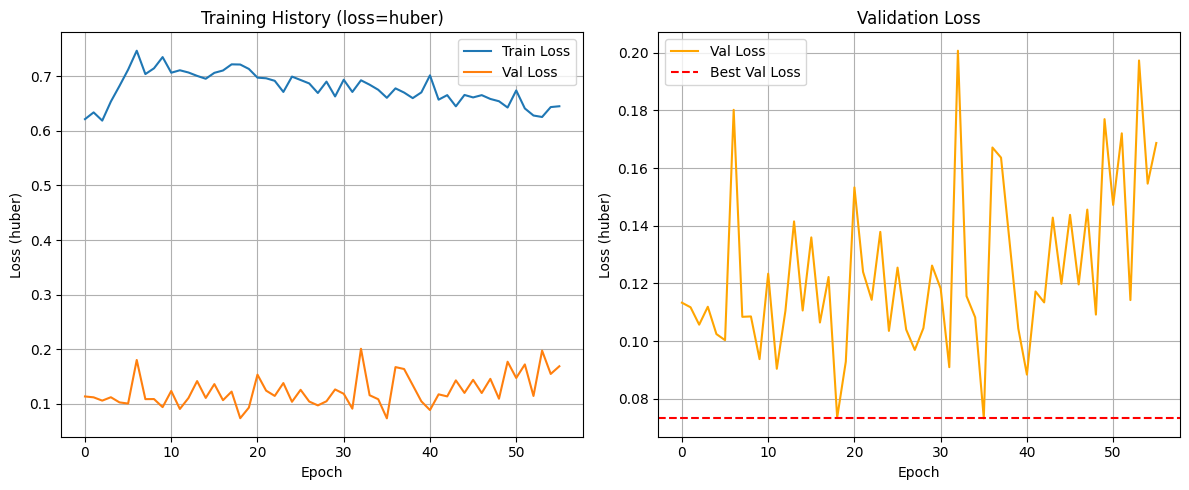

In [67]:
import matplotlib.pyplot as plt

loss_type = str(config.get("loss_type", "mse")).lower()
train_losses = result.get("train_losses", [])
val_losses = result.get("val_losses", [])
best_val_loss = result.get("best_val_loss", None)

if not train_losses:
    raise ValueError("Missing training history in `result`. Run training first.")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
if val_losses:
    plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel(f"Loss ({loss_type})")
plt.title(f"Training History (loss={loss_type})")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
if val_losses:
    plt.plot(val_losses, label="Val Loss", color="orange")
    if best_val_loss is not None:
        plt.axhline(y=best_val_loss, color="r", linestyle="--", label="Best Val Loss")
    plt.legend()
plt.xlabel("Epoch")
plt.ylabel(f"Loss ({loss_type})")
plt.title("Validation Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

## Cell 15: Evaluate Model (Most Recent Run)

In [ ]:
import numpy as np

# Evaluate on validation set
metrics = engine.evaluate(X_val, y_val)

print("Validation Metrics:")
for key, value in metrics.items():
    print(f"  {key}: {value:.6f}")

loss_type = str(config.get("loss_type", "mse")).lower()
if loss_type == "mse" and result.get("val_losses") is not None and len(result.get("val_losses", [])) > 0:
    print(f"\nSanity check (MSE units):")
    print(f"  last val_loss (training): {result['val_losses'][-1]:.6f}")
    print(f"  eval mse (engine.evaluate): {metrics['mse']:.6f}")

print("\nTarget stats (y_val):")
print(f"  min={float(np.min(y_val)):.6f} max={float(np.max(y_val)):.6f} mean={float(np.mean(y_val)):.6f} std={float(np.std(y_val)):.6f}")

## Cell 17: Download Trained Model (Final Step)

This downloads a zip containing `trained_data/` and `config.yaml` after all training has completed.

In [66]:
from google.colab import files
from pathlib import Path
import shutil

# Bundle trained artifacts (runs last)
repo_root = Path.cwd()
trained_dir = repo_root / 'trained_data'
if not trained_dir.exists():
    raise FileNotFoundError(f"Missing {trained_dir} - run training first")

export_dir = repo_root / 'export_trained_artifacts'
if export_dir.exists():
    shutil.rmtree(export_dir)
export_dir.mkdir(parents=True, exist_ok=True)

# Include trained_data + config.yaml
shutil.copy2(repo_root / 'config.yaml', export_dir / 'config.yaml')
shutil.copytree(trained_dir, export_dir / 'trained_data')

archive_base = repo_root / 'trained_artifacts'
zip_path = shutil.make_archive(str(archive_base), 'zip', export_dir)

files.download(zip_path)
print(f"\nDownloaded: {zip_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded: /content/ml_engine/trained_artifacts.zip
